# Exploratory Data Analysis

### Data Science Process

<img src='https://www.springboard.com/blog/wp-content/uploads/2022/05/data-science-life-cycle.png' alt='data science process' />

### Activities in the Data Science Process

* Collection
    * Observational: Observing behaviors, open-ended surveys, sensors, real-time
    * Experimental: Active intervention by the researcher to produce and measure change, determine relationships, and causation, inference
    * Simulation: Imitation, what if, real-life simulations
    * Derived: Using existing data to create new data through transformation
* Cleaning
    * Identify and fix incorrect data
    * Cardinality, duplicates, corrupt, inaccurate, format, incomplete (missing), irrelevant
    * Outliers
    * Language translation
* Exploratory Data Analysis
    * Descriptive statistics
    * Correlation
    * Feature engineering
    * Feature selections
    * Univariate, multivariate analysis
    * Balancing data
* Model Building
    * Algorithms
    * Tuning hyperparameters
    * Addressing overfitting / underfitting
    * Bias variance tradeoff
    * Metrics
* Deployment
    * Continuous integration and continuous deployment
    * Hardware
    * MLOps
    * Model versioning, model artifacts, lifecycle
    * Clusters, Docker, Cloud, Kubernetes
    * Model drift
    
Sources:

* https://libguides.macalester.edu/c.php?g=527786/&p=3608643
* https://www.knowledgehut.com/blog/data-science/data-cleaning
* https://www.databricks.com/glossary/mlops

## Data Analysis

### Univariate Analysis

Univariate analysis is the simplest form of analyzing data. Uni means one, so in other words the data has only one variable... Univariate data does not answer questions about relationships between variables, but rather it is used to describe characteristics or attributes of a feature... (para 4).

https://en.wikipedia.org/wiki/Univariate_(statistics).

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0      130.0  3504.0          12.0          70   
1  15.0          8         350.0      165.0  3693.0          11.5          70   
2  18.0          8         318.0      150.0  3436.0          11.0          70   
3  16.0          8         304.0      150.0  3433.0          12.0          70   
4  17.0          8         302.0      140.0  3449.0          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


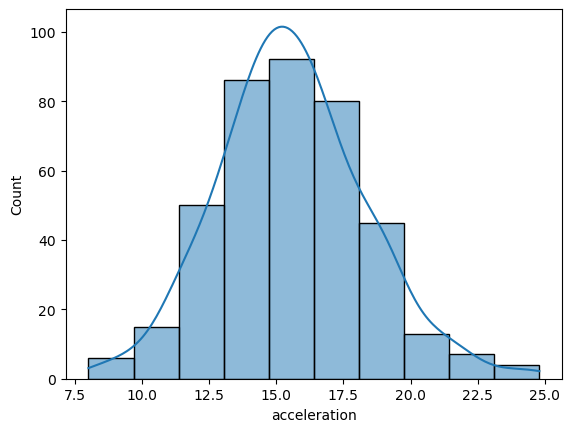

In [1]:
# univariate data histogram: dataset from https://archive.ics.uci.edu/ml/datasets/Auto+MPG
import pandas as pd
import seaborn as sns

cars = pd.read_csv('https://raw.githubusercontent.com/gitmystuff/INFO5502/main/Week_3-Data/auto-mpg.data', sep = '\s+', header = None)
cars.columns=['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin',  'car name']
print(cars.head())
sns.histplot(cars['acceleration'].dropna(), kde=True, bins=10);

**Note on sns.histplot(data, kde=True, bins=10) in previous cell**

* Kernel density estimation or KDE is a non-parametric way to estimate the probability density function of a random variable
* The aim of KDE is to find probability density function (PDF) for a given dataset

https://www.homeworkhelponline.net/blog/math/tutorial-kde

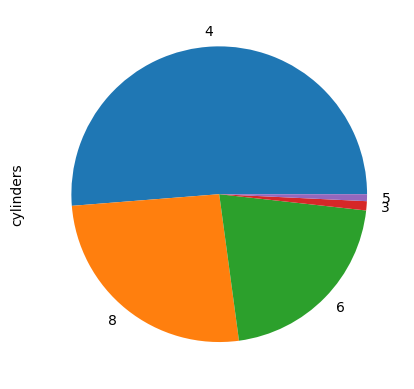

In [2]:
# univariate data with pie chart
cars['cylinders'].value_counts().plot.pie();

### Bivariate Analysis

Can be used to describe the relationship between two variables

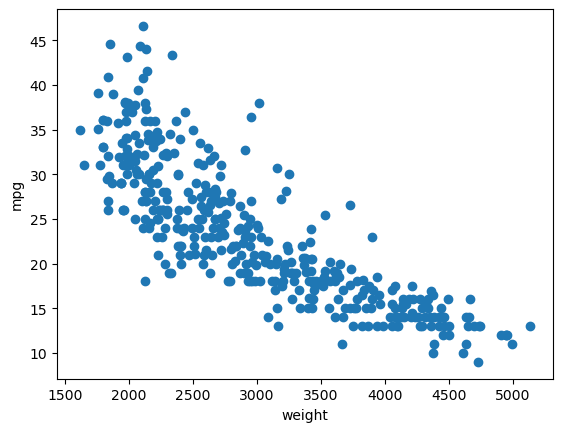

In [3]:
# bivariate scatter plot
import matplotlib.pyplot as plt

plt.scatter(cars['weight'], cars['mpg'])
plt.xlabel('weight')
plt.ylabel('mpg')
plt.show()

### Multivariate Analysis

Multivariate data involves two or more variables and provides another visual dimension

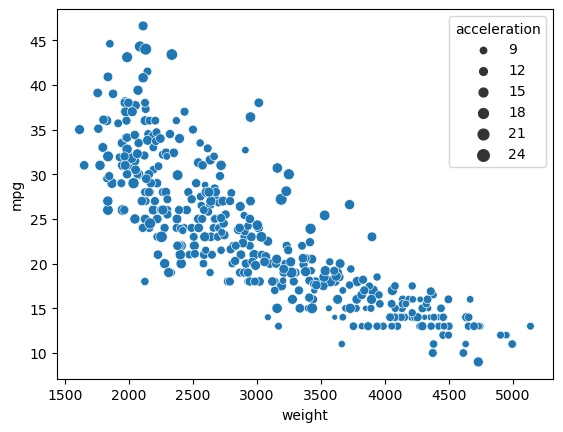

In [4]:
# multivariate example
import seaborn as sns

sns.scatterplot(data=cars, x='weight', y='mpg', size='acceleration');

## Exploratory Data Analysis

* Getting to know your data: center, spread, shape
* Data types: numerical, categorical, nominal, ordinal, boolean
* Cardinality, duplications, and missing data
* Outliers
* Engineer features with too many labels
* Understanding relationships between variables: feature with feature, feature with target
* Feature engineering
* Feature selection

In [5]:
# get data
import pandas as pd

grades = pd.read_csv('https://raw.githubusercontent.com/gitmystuff/Datasets/main/class-grades4.csv', index_col=0)
grades.drop(['index'], axis=1, inplace=True)
print(grades.shape)
print(grades.info())
grades.head()

(103, 17)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 103 entries, 0 to 102
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Prefix       103 non-null    float64
 1   Assignment1  99 non-null     float64
 2   Tutorial     92 non-null     float64
 3   Midterm      95 non-null     float64
 4   Quiz         95 non-null     float64
 5   Final        99 non-null     float64
 6   TakeHome     96 non-null     object 
 7   Student      103 non-null    int64  
 8   Misc         2 non-null      float64
 9   Nothing      0 non-null      float64
 10  FinalGrade   99 non-null     float64
 11  work_status  96 non-null     object 
 12  scholarship  103 non-null    object 
 13  name         103 non-null    object 
 14  age          103 non-null    float64
 15  sex          103 non-null    object 
 16  home.dest    71 non-null     object 
dtypes: float64(10), int64(1), object(6)
memory usage: 14.5+ KB
None


,Prefix,Assignment1,Tutorial,Midterm,Quiz,Final,TakeHome,Student,Misc,Nothing,FinalGrade,work_status,scholarship,name,age,sex,home.dest
0,4.0,86.86,62.64,61.0,61.0,62.78,B,1,NaN,NaN,71.0,not_employed,no,"Rice, Master. Albert",10.0,male,NaN
1,4.0,87.93,99.47,72.0,72.0,61.11,B,1,NaN,NaN,71.0,not_employed,no,"Goodwin, Miss. Jessie Allis",10.0,female,"Wiltshire, England Niagara Falls, NY"
2,5.0,57.14,34.09,72.0,72.0,52.50,F,1,0.0,NaN,54.0,half_time,no,"Goodwin, Master. William Frederick",11.0,male,"Wiltshire, England Niagara Falls, NY"
3,6.0,90.74,89.64,NaN,NaN,NaN,A,1,NaN,NaN,NaN,not_employed,no,"Carter, Master. William Thornton II",11.0,male,"Bryn Mawr, PA"
4,6.0,28.14,58.51,71.0,71.0,68.33,D,1,NaN,NaN,60.0,not_employed,yes,"Andersson, Miss. Sigrid Elisabeth",11.0,female,"Sweden Winnipeg, MN"


### Constant Features (Low Cardinality)

* The number of unique categories in a variable is called cardinality

In [6]:
# replace missing values and then check how many unique values are in each variable
few_values = [
    feat for feat in grades.columns if len(grades[feat].fillna(0).unique()) == 1
]

few_values

['Student', 'Misc', 'Nothing']

### Quasi Constant Features

In [7]:
# quasi constant values (sometimes these may be boolean features)
for feat in grades.columns.sort_values():
    if (len(grades[feat].unique()) < 3):
        print(grades[feat].value_counts())

0.0    2
Name: Misc, dtype: int64
Series([], Name: Nothing, dtype: int64)
1    103
Name: Student, dtype: int64
yes    66
no     37
Name: scholarship, dtype: int64
male      55
female    48
Name: sex, dtype: int64


### High Cardinality

In [8]:
# high cardinality (hc)
hc = 10

for feat in grades.select_dtypes(include=['object']).columns.sort_values():
    if (len(grades[feat].unique()) > hc):
        print(feat)

home.dest
name


### Duplicates

In [9]:
# duplicate rows
grades[grades.duplicated(keep=False)]

,Prefix,Assignment1,Tutorial,Midterm,Quiz,Final,TakeHome,Student,Misc,Nothing,FinalGrade,work_status,scholarship,name,age,sex,home.dest
1,4.0,87.93,99.47,72.0,72.0,61.11,B,1,NaN,NaN,71.0,not_employed,no,"Goodwin, Miss. Jessie Allis",10.0,female,"Wiltshire, England Niagara Falls, NY"
2,5.0,57.14,34.09,72.0,72.0,52.50,F,1,0.0,NaN,54.0,half_time,no,"Goodwin, Master. William Frederick",11.0,male,"Wiltshire, England Niagara Falls, NY"
3,6.0,90.74,89.64,NaN,NaN,NaN,A,1,NaN,NaN,NaN,not_employed,no,"Carter, Master. William Thornton II",11.0,male,"Bryn Mawr, PA"
4,6.0,28.14,58.51,71.0,71.0,68.33,D,1,NaN,NaN,60.0,not_employed,yes,"Andersson, Miss. Sigrid Elisabeth",11.0,female,"Sweden Winnipeg, MN"
99,4.0,87.93,99.47,72.0,72.0,61.11,B,1,NaN,NaN,71.0,not_employed,no,"Goodwin, Miss. Jessie Allis",10.0,female,"Wiltshire, England Niagara Falls, NY"
100,5.0,57.14,34.09,72.0,72.0,52.50,F,1,0.0,NaN,54.0,half_time,no,"Goodwin, Master. William Frederick",11.0,male,"Wiltshire, England Niagara Falls, NY"
101,6.0,90.74,89.64,NaN,NaN,NaN,A,1,NaN,NaN,NaN,not_employed,no,"Carter, Master. William Thornton II",11.0,male,"Bryn Mawr, PA"
102,6.0,28.14,58.51,71.0,71.0,68.33,D,1,NaN,NaN,60.0,not_employed,yes,"Andersson, Miss. Sigrid Elisabeth",11.0,female,"Sweden Winnipeg, MN"


In [10]:
# drop duplicate rows
grades.drop_duplicates(inplace=True)

In [11]:
# check of duplicate columns
duplicate_variables = []
for i in range(0, len(grades.columns)):
    orig = grades.columns[i]

    for dupe in grades.columns[i + 1:]:
        if grades[orig].equals(grades[dupe]):
            duplicate_variables.append(dupe)
            print(f'{orig} looks the same as {dupe}')
            
duplicate_variables

Midterm looks the same as Quiz


['Quiz']

In [12]:
# drop the variables that are duplicated or low in variance
grades.drop(['Quiz', 'Student', 'Misc', 'Nothing'], axis=1, inplace=True)
grades.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 99 entries, 0 to 98
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Prefix       99 non-null     float64
 1   Assignment1  95 non-null     float64
 2   Tutorial     88 non-null     float64
 3   Midterm      92 non-null     float64
 4   Final        96 non-null     float64
 5   TakeHome     92 non-null     object 
 6   FinalGrade   96 non-null     float64
 7   work_status  92 non-null     object 
 8   scholarship  99 non-null     object 
 9   name         99 non-null     object 
 10  age          99 non-null     float64
 11  sex          99 non-null     object 
 12  home.dest    67 non-null     object 
dtypes: float64(7), object(6)
memory usage: 10.8+ KB


### Missingness

Missing data cause problems because most statistical procedures require a value for each variable. When a data set is incomplete, the data analyst has to decide how to deal with it.

https://www.theanalysisfactor.com/causes-of-missing-data/<br />
https://www.theanalysisfactor.com/when-listwise-deletion-works/

* MCAR: Missing Completely at Random
    * Probability of missing is same for all cases
    * I tripped and broke the test tubes I was carrying
    * Missing because not sampled
* MNAR: Missing Not at Random
    * Probability of missing is not the same for all cases
    * Data are missing on IQ and only the people with low IQ values have missing observations for this variable
    * Missing from public opinion because respondent maybe inhibited or have bias
* MAR: Mising at Random
    * Probability of missing is the same only within groups
    * Probability of sample depends on some known property
    * Only people with low credit scores have omitted their credit scores

https://stefvanbuuren.name/fimd/sec-MCAR.html<br />
https://www.iriseekhout.com/post/2022-06-28-missingdatamechanisms/

### Complete-Case Analysis (CCA)

* Aka Listwise deletion
* Reduces sample size
* Can reduce the statistical efficiency of estimates

In [13]:
# cca example
import pandas as pd

houses = pd.read_csv('https://raw.githubusercontent.com/gitmystuff/INFO4050/main/Datasets/house-prices.csv') 
houses.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [14]:
# delete rows with missing values
print(houses.shape)
print(houses.dropna().shape)

(1460, 81)
(0, 81)


### Any vs All

In [15]:
# any vs all example
import pandas as pd

houses = pd.read_csv('https://raw.githubusercontent.com/gitmystuff/INFO4050/main/Datasets/house-prices.csv') 
houses.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [16]:
# count nulls
houses.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [17]:
# drop columns where all values are empty
print(houses.shape)
houses.dropna(how='all', axis='columns', inplace=True) # 1
print(houses.shape)

(1460, 81)
(1460, 81)


In [18]:
# drop columns where any values are empty
print(houses.shape)
houses.dropna(how='any', axis='columns', inplace=True) # 1
print(houses.shape)

(1460, 81)
(1460, 62)


In [19]:
# drop rows where any values are empty
import pandas as pd

houses = pd.read_csv('https://raw.githubusercontent.com/gitmystuff/INFO4050/main/Datasets/house-prices.csv') 
print(houses.shape)
houses.dropna(how='any', axis='index', inplace=True) # 1
print(houses.shape)

(1460, 81)
(0, 81)


### Back to Grades

In [20]:
# check for nulls
grades.isnull().sum()

Prefix          0
Assignment1     4
Tutorial       11
Midterm         7
Final           3
TakeHome        7
FinalGrade      3
work_status     7
scholarship     0
name            0
age             0
sex             0
home.dest      32
dtype: int64

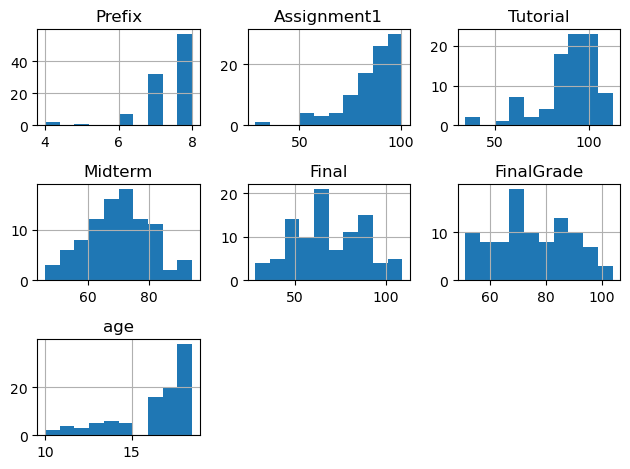

In [21]:
# look at the shape of variables that are numerical
import matplotlib.pyplot as plt

grades.hist()
plt.tight_layout();

In [22]:
# impute missing values with mean and median
grades['Midterm'].fillna(round(grades['Midterm'].mean(), 2), inplace=True)
grades['Final'].fillna(round(grades['Final'].mean(), 2), inplace=True)
grades['FinalGrade'].fillna(round(grades['FinalGrade'].mean(), 2), inplace=True)
grades['Assignment1'].fillna(grades['Assignment1'].median(), inplace=True)
grades['Tutorial'].fillna(grades['Tutorial'].median(), inplace=True)
grades.isnull().sum()

Prefix          0
Assignment1     0
Tutorial        0
Midterm         0
Final           0
TakeHome        7
FinalGrade      0
work_status     7
scholarship     0
name            0
age             0
sex             0
home.dest      32
dtype: int64

In [23]:
# impute missing values with mode
print(grades['TakeHome'].value_counts(dropna=False))
print(grades['work_status'].value_counts(dropna=False))

A      43
B      18
D      12
C      10
F       9
NaN     7
Name: TakeHome, dtype: int64
not_employed    47
half_time       35
full_time       10
NaN              7
Name: work_status, dtype: int64


In [24]:
# replace work_status with mode (not employed)
grades['work_status'].fillna(grades['work_status'].mode()[0], inplace=True)
grades.isnull().sum()

Prefix          0
Assignment1     0
Tutorial        0
Midterm         0
Final           0
TakeHome        7
FinalGrade      0
work_status     0
scholarship     0
name            0
age             0
sex             0
home.dest      32
dtype: int64

In [25]:
# replace TakeHome with function
def convert_grade(row):
    if len(str(row['TakeHome'])) > 1:
        if row['Final'] >= 90:
            return 'A'
        if row['Final'] >= 80:
            return 'B'
        if row['Final'] >= 70:
            return 'C'
        if row['Final'] >= 60:
            return 'D'
        if row['Final'] < 60:
            return 'F'
    else:
        return row['TakeHome']
        
grades['TakeHome'] = grades.apply(convert_grade, axis=1)
grades['TakeHome'].fillna('Missing', inplace=True)
print(grades['TakeHome'].value_counts())
print(grades.isnull().sum())

A    43
B    19
D    14
F    13
C    10
Name: TakeHome, dtype: int64
Prefix          0
Assignment1     0
Tutorial        0
Midterm         0
Final           0
TakeHome        0
FinalGrade      0
work_status     0
scholarship     0
name            0
age             0
sex             0
home.dest      32
dtype: int64


### Engineer Features With Too Many Labels

In [26]:
# how many different home destination labels are there?
grades['home.dest'].value_counts(dropna=False).sum()

99

In [27]:
# null home.dest values?
print(len(grades[grades['home.dest'].isnull()]))
grades[grades['home.dest'].isnull()]

32


,Prefix,Assignment1,Tutorial,Midterm,Final,TakeHome,FinalGrade,work_status,scholarship,name,age,sex,home.dest
0,4.0,86.86,62.640,61.00,62.78,B,71.0,not_employed,no,"Rice, Master. Albert",10.0,male,NaN
5,6.0,57.14,34.090,59.00,55.83,F,56.0,half_time,yes,"Hassan, Mr. Houssein G N",11.0,male,NaN
8,6.0,98.49,92.865,69.00,39.44,F,56.0,not_employed,yes,"Nicola-Yarred, Master. Elias",12.0,male,NaN
17,7.0,93.83,57.320,69.88,45.56,C,51.0,not_employed,no,"Panula, Mr. Jaako Arnold",14.0,male,NaN
19,7.0,98.58,88.300,81.00,99.17,A,93.0,half_time,yes,"Nicola-Yarred, Miss. Jamila",14.0,female,NaN
22,7.0,89.89,57.970,72.00,51.67,B,53.0,not_employed,yes,"McGowan, Miss. Anna ""Annie""",15.0,female,NaN
24,7.0,84.26,91.310,63.00,75.56,B,75.0,not_employed,no,"Najib, Miss. Adele Kiamie ""Jane""",15.0,female,NaN
25,7.0,74.35,92.930,80.00,73.89,C,83.0,half_time,no,"de Pelsmaeker, Mr. Alfons",16.0,male,NaN
28,7.0,72.85,86.850,67.00,46.67,D,58.0,not_employed,yes,"Osen, Mr. Olaf Elon",16.0,male,NaN
31,7.0,98.58,91.030,60.00,107.78,A,100.0,half_time,yes,"Panula, Mr. Ernesti Arvid",16.0,male,NaN


In [28]:
import re

def cat_home(r):
    text = str(r['home.dest']).strip()
    if bool(re.search('[A-Z]{2}$', text[-2:])):
        return 'North America'
    elif text == 'nan':
        return 'Missing'
    else:
        return 'Not North America'

grades['cat_home'] = grades.apply(cat_home, axis=1)

print(grades['cat_home'].value_counts())
grades.head()

North America        53
Missing              32
Not North America    14
Name: cat_home, dtype: int64


,Prefix,Assignment1,Tutorial,Midterm,Final,TakeHome,FinalGrade,work_status,scholarship,name,age,sex,home.dest,cat_home
0,4.0,86.86,62.64,61.00,62.78,B,71.00,not_employed,no,"Rice, Master. Albert",10.0,male,NaN,Missing
1,4.0,87.93,99.47,72.00,61.11,B,71.00,not_employed,no,"Goodwin, Miss. Jessie Allis",10.0,female,"Wiltshire, England Niagara Falls, NY",North America
2,5.0,57.14,34.09,72.00,52.50,F,54.00,half_time,no,"Goodwin, Master. William Frederick",11.0,male,"Wiltshire, England Niagara Falls, NY",North America
3,6.0,90.74,89.64,69.88,68.41,A,75.44,not_employed,no,"Carter, Master. William Thornton II",11.0,male,"Bryn Mawr, PA",North America
4,6.0,28.14,58.51,71.00,68.33,D,60.00,not_employed,yes,"Andersson, Miss. Sigrid Elisabeth",11.0,female,"Sweden Winnipeg, MN",North America


# Outliers

https://en.wikipedia.org/wiki/Interquartile_range

Interquartile range<br />
Whiskers<br />
Fence: https://www.statisticshowto.com/upper-and-lower-fences/

Outliers<br />
Boxplots<br />
Violin plots

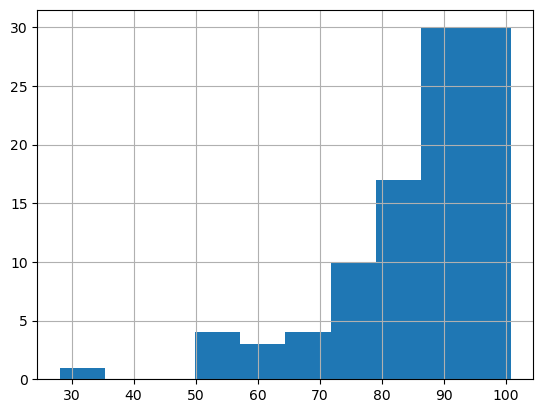

In [29]:
# Assignment histogram
grades['Assignment1'].hist();

<AxesSubplot: >

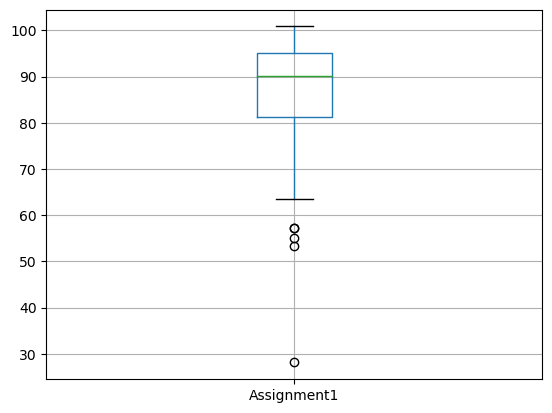

In [30]:
# Assignment boxplot
grades.boxplot(column=['Assignment1'])

<AxesSubplot: xlabel='Assignment1'>

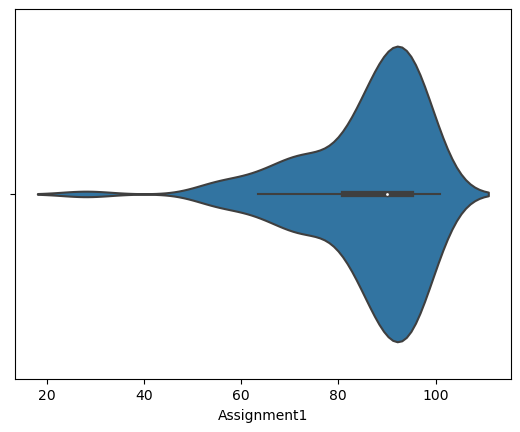

In [31]:
# Assignment violinplot
import seaborn as sns

sns.violinplot(x=grades['Assignment1'])

In [32]:
for feat in grades._get_numeric_data().columns[1:]:
    q1 = grades[feat].quantile(0.25)
    q3 = grades[feat].quantile(0.75)
    iqr = q3 - q1
    lower_fence = (q1 - 1.5 * iqr).round()
    upper_fence = (q3 + 1.5 * iqr).round()
    lower_count = grades[feat][grades[feat] < lower_fence].count()
    upper_count = grades[feat][grades[feat] > upper_fence].count()
    print(f'{feat} outliers = {lower_count + upper_count}: lower_fence: {lower_fence}, upper_fence: {upper_fence}, lower_count: {lower_count}, upper_count: {upper_count}')

Assignment1 outliers = 5: lower_fence: 61.0, upper_fence: 116.0, lower_count: 5, upper_count: 0
Tutorial outliers = 11: lower_fence: 68.0, upper_fence: 117.0, lower_count: 11, upper_count: 0
Midterm outliers = 0: lower_fence: 44.0, upper_fence: 96.0, lower_count: 0, upper_count: 0
Final outliers = 0: lower_fence: 10.0, upper_fence: 128.0, lower_count: 0, upper_count: 0
FinalGrade outliers = 0: lower_fence: 36.0, upper_fence: 116.0, lower_count: 0, upper_count: 0
age outliers = 6: lower_fence: 12.0, upper_fence: 22.0, lower_count: 6, upper_count: 0


### Handling Outliers

https://www.projectpro.io/recipes/deal-with-outliers-in-python

* Drop
* Mark
* Rescale

### Scalers

https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html

* from sklearn.preprocessing import MinMaxScaler
* from sklearn.preprocessing import minmax_scale
* from sklearn.preprocessing import MaxAbsScaler
* from sklearn.preprocessing import StandardScaler
* from sklearn.preprocessing import RobustScaler
* from sklearn.preprocessing import Normalizer
* from sklearn.preprocessing import QuantileTransformer
* from sklearn.preprocessing import PowerTransformer

In [33]:
# PowerTransformer scaler for outliers
# from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import PowerTransformer

feat_scales = ['Assignment1', 'Tutorial', 'age']

scaler = PowerTransformer()

for feat in feat_scales:
    grades[feat] = scaler.fit_transform(grades[feat].values.reshape(-1,1))


<AxesSubplot: xlabel='Assignment1'>

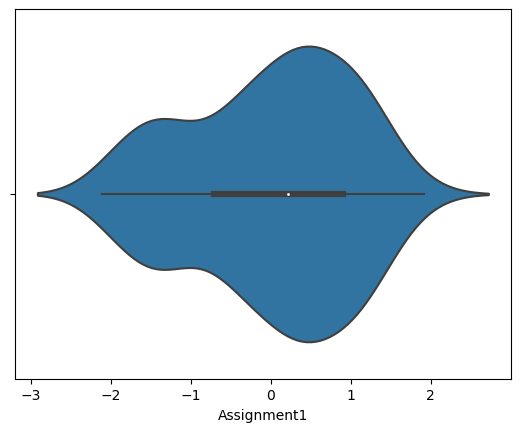

In [34]:
# Assignment violinplot
import seaborn as sns

sns.violinplot(x=grades['Assignment1'])

In [35]:
for feat in grades._get_numeric_data().columns[1:]:
    q1 = grades[feat].quantile(0.25)
    q3 = grades[feat].quantile(0.75)
    iqr = q3 - q1
    lower_fence = (q1 - 1.5 * iqr).round()
    upper_fence = (q3 + 1.5 * iqr).round()
    lower_count = grades[feat][grades[feat] < lower_fence].count()
    upper_count = grades[feat][grades[feat] > upper_fence].count()
    print(f'{feat} outliers = {lower_count + upper_count}: lower_fence: {lower_fence}, upper_fence: {upper_fence}, lower_count: {lower_count}, upper_count: {upper_count}')

Assignment1 outliers = 0: lower_fence: -3.0, upper_fence: 3.0, lower_count: 0, upper_count: 0
Tutorial outliers = 3: lower_fence: -2.0, upper_fence: 2.0, lower_count: 2, upper_count: 1
Midterm outliers = 0: lower_fence: 44.0, upper_fence: 96.0, lower_count: 0, upper_count: 0
Final outliers = 0: lower_fence: 10.0, upper_fence: 128.0, lower_count: 0, upper_count: 0
FinalGrade outliers = 0: lower_fence: 36.0, upper_fence: 116.0, lower_count: 0, upper_count: 0
age outliers = 0: lower_fence: -3.0, upper_fence: 4.0, lower_count: 0, upper_count: 0
